# Fintech Product Funnel & Activation Analysis

## Objective

This project analyzes a synthetic fintech app dataset to understand how users move from signup to meaningful product activation.

The analysis focuses on:

1. onboarding funnel drop-off,
2. KYC completion,
3. first deposit conversion,
4. first transaction conversion,
5. 14-day activation,
6. acquisition channel quality,
7. incentive profitability,
8. cohort retention.

The goal is to produce a business-readable product analytics case study using Python, SQL, SQLite, pandas, and matplotlib.

## Business Context

A consumer fintech product does not create value when a user merely signs up. Value starts when the user completes onboarding, passes compliance checks, funds the account, and performs a first transaction.

For this analysis, the core user journey is:

```text
Signup → Verification → KYC Submission → KYC Approval → First Deposit → First Transaction
```

A user is considered activated if they complete a first transaction within 14 days of signup.

This definition is intentionally strict: it measures whether the user reaches meaningful product value early enough to indicate genuine engagement.

In [1]:
from pathlib import Path

import sys

import pandas as pd

import matplotlib.pyplot as plt

import sqlite3

# Make src/ importable from the notebook

PROJECT_ROOT = Path.cwd().parents[0] if Path.cwd().name == "notebooks" else Path.cwd()

sys.path.append(str(PROJECT_ROOT))

from src.metrics import (

    load_processed_csv,

    calculate_percentage_point_gap,

    get_top_row,

    get_bottom_row,

)

DATA_PROCESSED = PROJECT_ROOT / "data" / "processed"

CHARTS_DIR = PROJECT_ROOT / "reports" / "charts"

DATABASE_PATH = DATA_PROCESSED / "fintech_funnel.db"

CHARTS_DIR.mkdir(parents=True, exist_ok=True)

pd.set_option("display.max_columns", 100)

pd.set_option("display.width", 120)

print("Project root:", PROJECT_ROOT)

print("Database path:", DATABASE_PATH)

Matplotlib is building the font cache; this may take a moment.


Project root: /Users/theboyyy/Work/Projects/fintech-funnel-analysis
Database path: /Users/theboyyy/Work/Projects/fintech-funnel-analysis/data/processed/fintech_funnel.db


In [2]:
funnel = load_processed_csv("funnel_analysis.csv")
activation = load_processed_csv("activation_metrics.csv")
channel_quality = load_processed_csv("channel_quality.csv")
incentive_profitability = load_processed_csv("incentive_profitability.csv")
cohort_retention = load_processed_csv("cohort_retention.csv")

print("Funnel:", funnel.shape)
print("Activation:", activation.shape)
print("Channel quality:", channel_quality.shape)
print("Incentive profitability:", incentive_profitability.shape)
print("Cohort retention:", cohort_retention.shape)

Funnel: (6, 7)
Activation: (11, 10)
Channel quality: (5, 16)
Incentive profitability: (5, 10)
Cohort retention: (14, 12)


## 1. Funnel Overview

The funnel shows how many users reach each major product milestone.

The key question is not only how many users signed up but also where users fail to progress toward meaningful fintech usage.

In [3]:
funnel

,step_order,funnel_step,users_count,conversion_from_previous_step_pct,conversion_from_signup_pct,dropoff_users,dropoff_from_previous_step_pct
0,1,Signup,10000,NaN,100.00,NaN,NaN
1,2,Verification Completed,8509,85.09,85.09,1491.0,14.91
2,3,KYC Submitted,6108,71.78,61.08,2401.0,28.22
3,4,KYC Approved,5041,82.53,50.41,1067.0,17.47
4,5,First Deposit,3696,73.32,36.96,1345.0,26.68
5,6,First Transaction,2920,79.00,29.20,776.0,21.00


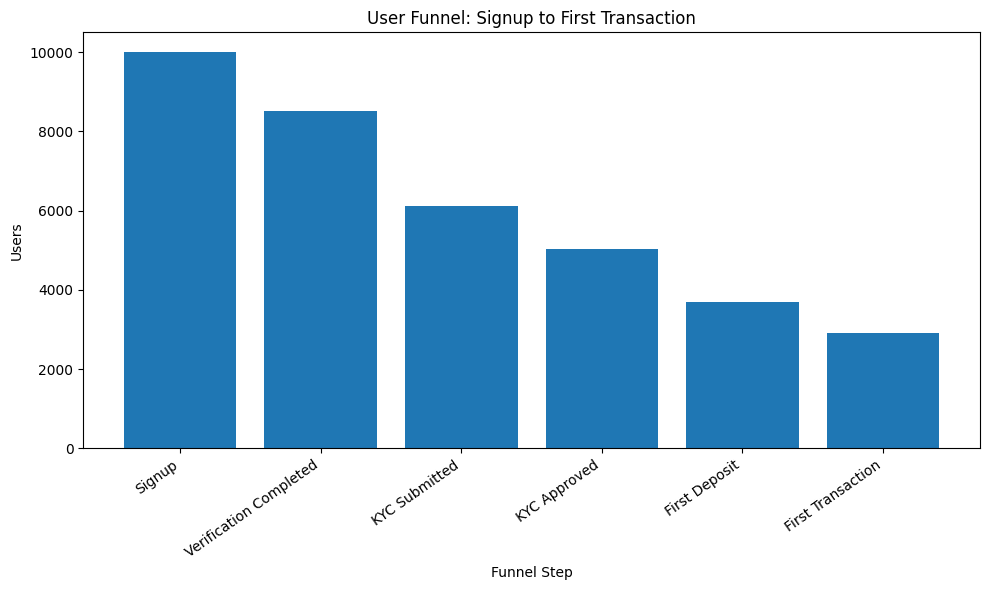

Saved chart to /Users/theboyyy/Work/Projects/fintech-funnel-analysis/reports/charts/user_funnel.png


In [4]:
plt.figure(figsize=(10, 6))
plt.bar(funnel["funnel_step"], funnel["users_count"])
plt.title("User Funnel: Signup to First Transaction")
plt.xlabel("Funnel Step")
plt.ylabel("Users")
plt.xticks(rotation=35, ha="right")
plt.tight_layout()

chart_path = CHARTS_DIR / "user_funnel.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved chart to {chart_path}")

In [5]:
largest_dropoff = funnel.dropna(subset=["dropoff_users"]).sort_values(
    "dropoff_users", ascending=False
).iloc[0]

final_conversion = funnel.loc[
    funnel["funnel_step"] == "First Transaction",
    "conversion_from_signup_pct"
].iloc[0]

print("Largest drop-off step:", largest_dropoff["funnel_step"])
print("Drop-off users:", int(largest_dropoff["dropoff_users"]))
print("Drop-off from previous step:", largest_dropoff["dropoff_from_previous_step_pct"])
print("Signup to first transaction conversion:", final_conversion)

Largest drop-off step: KYC Submitted
Drop-off users: 2401
Drop-off from previous step: 28.22
Signup to first transaction conversion: 29.2


### Funnel Interpretation

Only 29.2% of signed-up users reached their first transaction.

The largest drop-off occurred before KYC submission. This suggests that many users complete verification but do not continue into the identity verification process.

The second major friction point is the transition from KYC approval to first deposit. This suggests that even after compliance approval, users may still need stronger prompts, clearer funding options, or more trust-building before depositing funds.

## 2. Activation Analysis

Activation is defined as completing a first transaction within 14 days of signup.

This metric is stricter than simple first transaction conversion because it captures whether users reach product value quickly.

In [6]:
overall_activation = activation[activation["segment_type"] == "overall"]
channel_activation = activation[activation["segment_type"] == "acquisition_channel"].copy()
device_activation = activation[activation["segment_type"] == "device_type"].copy()
incentive_activation = activation[activation["segment_type"] == "incentive_offered"].copy()

overall_activation

,segment_type,segment_value,users_count,deposit_users,transaction_users,activated_14d_users,deposit_rate_pct,transaction_rate_pct,activation_14d_rate_pct,avg_days_to_first_transaction
10,overall,all_users,10000,3696,2920,2870,36.96,29.2,28.7,8.87


In [7]:
channel_activation.sort_values("activation_14d_rate_pct", ascending=False)

,segment_type,segment_value,users_count,deposit_users,transaction_users,activated_14d_users,deposit_rate_pct,transaction_rate_pct,activation_14d_rate_pct,avg_days_to_first_transaction
0,acquisition_channel,referral,1707,864,719,702,50.62,42.12,41.12,8.86
1,acquisition_channel,paid_search,2170,942,764,754,43.41,35.21,34.75,8.97
2,acquisition_channel,organic,2814,1027,820,811,36.50,29.14,28.82,8.85
3,acquisition_channel,affiliate,778,210,149,145,26.99,19.15,18.64,9.09
4,acquisition_channel,paid_social,2531,653,468,458,25.80,18.49,18.10,8.70


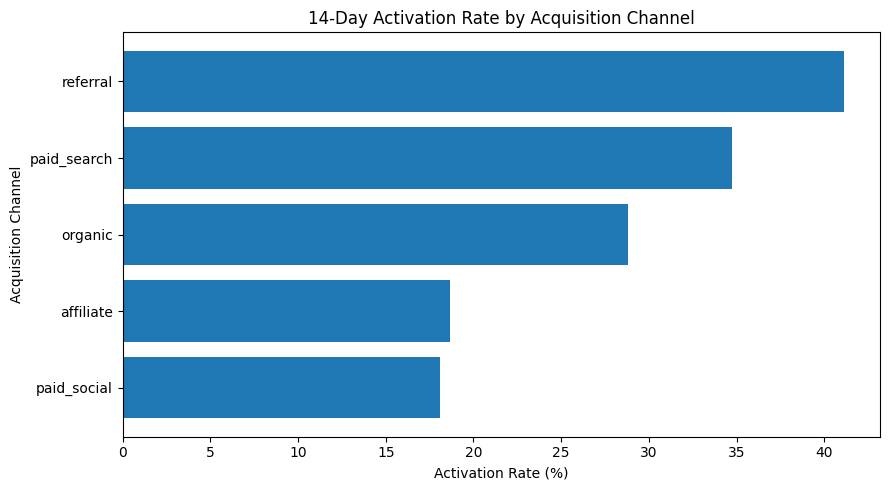

Saved chart to /Users/theboyyy/Work/Projects/fintech-funnel-analysis/reports/charts/activation_by_channel.png


In [8]:
channel_activation_sorted = channel_activation.sort_values(
    "activation_14d_rate_pct", ascending=True
)

plt.figure(figsize=(9, 5))
plt.barh(
    channel_activation_sorted["segment_value"],
    channel_activation_sorted["activation_14d_rate_pct"],
)
plt.title("14-Day Activation Rate by Acquisition Channel")
plt.xlabel("Activation Rate (%)")
plt.ylabel("Acquisition Channel")
plt.tight_layout()

chart_path = CHARTS_DIR / "activation_by_channel.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved chart to {chart_path}")

In [9]:
activation_gap = calculate_percentage_point_gap(
    channel_activation,
    group_column="segment_value",
    metric_column="activation_14d_rate_pct",
    high_group="referral",
    low_group="paid_social",
)

top_channel = get_top_row(channel_activation, "activation_14d_rate_pct")
bottom_channel = get_bottom_row(channel_activation, "activation_14d_rate_pct")

print(f"Top activation channel: {top_channel['segment_value']} ({top_channel['activation_14d_rate_pct']}%)")
print(f"Lowest activation channel: {bottom_channel['segment_value']} ({bottom_channel['activation_14d_rate_pct']}%)")
print(f"Referral vs paid social activation gap: {activation_gap} percentage points")

Top activation channel: referral (41.12%)
Lowest activation channel: paid_social (18.1%)
Referral vs paid social activation gap: 23.02 percentage points


### Activation Interpretation

Referral users had the highest 14-day activation rate, while paid social users had the weakest activation rate.

The gap between referral and paid social activation is 23.02 percentage points. This suggests that paid social may be driving top-of-funnel volume but lower-intent users.

Paid search also performs well, suggesting that users arriving with explicit product intent are more likely to complete the fintech value journey.

## 3. Acquisition Channel Quality

Activation alone is not enough. A channel can activate users but still be commercially weak if it requires heavy incentives or generates low transaction volume.

This section compares channels using activation, transaction volume, estimated revenue, incentive cost, and net profit.

In [10]:
channel_quality.sort_values("activation_14d_rate_pct", ascending=False)

,acquisition_channel,users_count,deposit_users,transaction_users,activated_14d_users,deposit_rate_pct,transaction_rate_pct,activation_14d_rate_pct,total_deposit_volume,total_transaction_volume,avg_deposit_amount_per_depositor,avg_transaction_volume_per_transacting_user,estimated_revenue_30d,incentive_cost,net_profit_30d,net_profit_per_user
0,referral,1707,864,719,702,50.62,42.12,41.12,36428.54,59250.53,42.16,82.41,1491.16,19452.0,-17960.84,-10.52
1,paid_search,2170,942,764,754,43.41,35.21,34.75,37570.04,53628.34,39.88,70.19,759.03,4480.0,-3720.97,-1.71
2,organic,2814,1027,820,811,36.50,29.14,28.82,42463.16,63840.37,41.35,77.85,242.10,2256.0,-2013.90,-0.72
3,affiliate,778,210,149,145,26.99,19.15,18.64,8343.04,8973.00,39.73,60.22,258.08,3780.0,-3521.92,-4.53
4,paid_social,2531,653,468,458,25.80,18.49,18.10,26757.38,24412.37,40.98,52.16,887.04,11312.0,-10424.96,-4.12


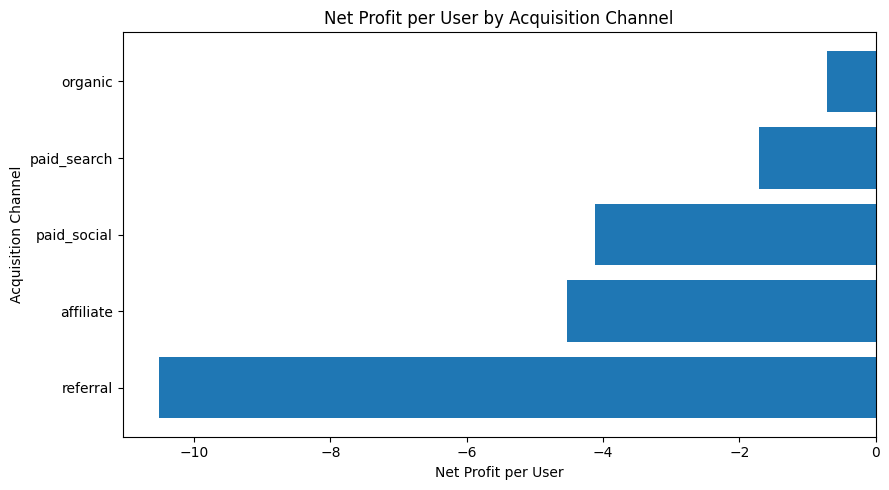

Saved chart to /Users/theboyyy/Work/Projects/fintech-funnel-analysis/reports/charts/net_profit_per_user_by_channel.png


In [11]:
channel_profit_sorted = channel_quality.sort_values("net_profit_per_user", ascending=True)

plt.figure(figsize=(9, 5))
plt.barh(
    channel_profit_sorted["acquisition_channel"],
    channel_profit_sorted["net_profit_per_user"],
)
plt.title("Net Profit per User by Acquisition Channel")
plt.xlabel("Net Profit per User")
plt.ylabel("Acquisition Channel")
plt.tight_layout()

chart_path = CHARTS_DIR / "net_profit_per_user_by_channel.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved chart to {chart_path}")

### Channel Quality Interpretation

Referral is the strongest channel by activation rate, but it is also the weakest by net profit per user because referral bonuses are expensive.

Organic does not have the highest activation rate, but it has the least negative net profit per user. This makes it strategically attractive because it is less dependent on subsidies.

Paid social combines weak activation with poor profitability, making it the least attractive channel in this synthetic dataset unless acquisition costs are very low or targeting improves.

## 4. Incentive Profitability

Incentives should not be evaluated only by activation lift. The better question is whether they create profitable activation.

This section compares incentive types by activation rate, total cost, estimated 30-day revenue, net profit, and cost per activated user.

In [12]:
incentive_profitability

,incentive_type,incentivized_users,activated_14d_users,activation_14d_rate_pct,total_incentive_cost,estimated_revenue_30d,net_profit_30d,net_profit_per_incentivized_user,revenue_to_cost_ratio,incentive_cost_per_activated_user
0,all_incentives,4591,1510,32.89,41280.0,3637.41,-37642.59,-8.20,0.088,27.34
1,cashback,896,360,40.18,4480.0,759.03,-3720.97,-4.15,0.169,12.44
2,welcome_bonus,1696,383,22.58,13568.0,1129.14,-12438.86,-7.33,0.083,35.43
3,affiliate_reward,378,92,24.34,3780.0,258.08,-3521.92,-9.32,0.068,41.09
4,referral_bonus,1621,675,41.64,19452.0,1491.16,-17960.84,-11.08,0.077,28.82


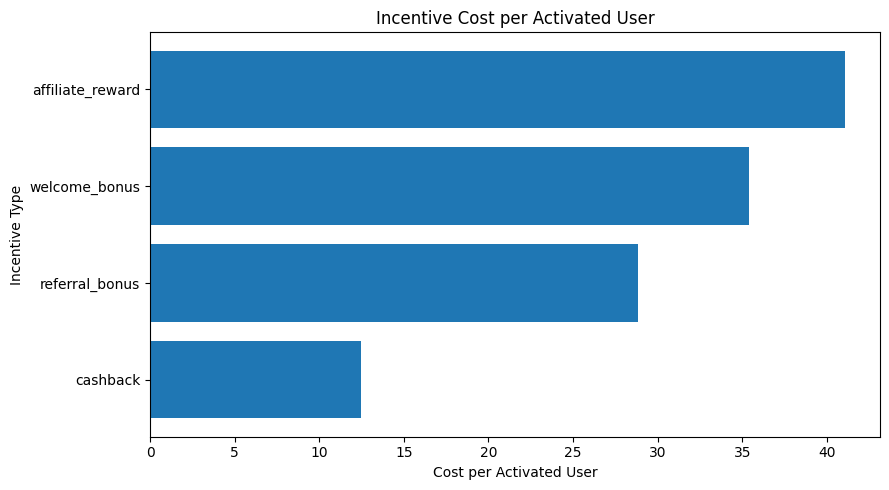

Saved chart to /Users/theboyyy/Work/Projects/fintech-funnel-analysis/reports/charts/incentive_cost_per_activated_user.png


In [13]:
incentive_types = incentive_profitability[
    incentive_profitability["incentive_type"] != "all_incentives"
].copy()

incentive_sorted = incentive_types.sort_values(
    "incentive_cost_per_activated_user",
    ascending=True
)

plt.figure(figsize=(9, 5))
plt.barh(
    incentive_sorted["incentive_type"],
    incentive_sorted["incentive_cost_per_activated_user"],
)
plt.title("Incentive Cost per Activated User")
plt.xlabel("Cost per Activated User")
plt.ylabel("Incentive Type")
plt.tight_layout()

chart_path = CHARTS_DIR / "incentive_cost_per_activated_user.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved chart to {chart_path}")

### Incentive Interpretation

Referral bonuses produce the highest activation rate, but they are expensive. Cashback produces a similar activation rate at a much lower cost per activated user.

Across all incentives, estimated 30-day revenue does not recover incentive costs. This suggests that incentives may improve activation but are inefficient under the current payout and revenue assumptions.

A better strategy would be to target incentives more selectively, reduce blanket payouts, and test lower-cost cashback-style incentives against referral bonuses.

## 5. Cohort Retention

Retention measures whether users continue transacting after signup.

Users are grouped by signup week. Retention weeks are measured relative to each user's own signup date:

- Week 0: days 0–6 after signup
- Week 1: days 7–13 after signup
- Week 2: days 14–20 after signup
- Week 3: days 21–27 after signup
- Week 4: days 28–34 after signup

In [14]:
cohort_retention

,signup_week,cohort_users,week_0_users,week_0_retention_pct,week_1_users,week_1_retention_pct,week_2_users,week_2_retention_pct,week_3_users,week_3_retention_pct,week_4_users,week_4_retention_pct
0,2024-12-30,531,37,6.97,127,23.92,46,8.66,53,9.98,49,9.23
1,2025-01-06,794,57,7.18,205,25.82,70,8.82,80,10.08,91,11.46
2,2025-01-13,807,69,8.55,210,26.02,86,10.66,84,10.41,85,10.53
3,2025-01-20,796,42,5.28,176,22.11,79,9.92,70,8.79,73,9.17
4,2025-01-27,784,50,6.38,193,24.62,88,11.22,76,9.69,82,10.46
5,2025-02-03,766,48,6.27,192,25.07,79,10.31,71,9.27,66,8.62
6,2025-02-10,829,51,6.15,208,25.09,92,11.10,87,10.49,73,8.81
7,2025-02-17,785,41,5.22,186,23.69,79,10.06,72,9.17,84,10.70
8,2025-02-24,744,56,7.53,179,24.06,76,10.22,85,11.42,78,10.48
9,2025-03-03,771,44,5.71,181,23.48,80,10.38,80,10.38,66,8.56


In [15]:
retention_summary = pd.DataFrame({
    "week": ["Week 0", "Week 1", "Week 2", "Week 3", "Week 4"],
    "avg_retention_pct": [
        cohort_retention["week_0_retention_pct"].mean(),
        cohort_retention["week_1_retention_pct"].mean(),
        cohort_retention["week_2_retention_pct"].mean(),
        cohort_retention["week_3_retention_pct"].mean(),
        cohort_retention["week_4_retention_pct"].mean(),
    ],
})

retention_summary

,week,avg_retention_pct
0,Week 0,6.425000
1,Week 1,24.307143
2,Week 2,10.388571
3,Week 3,10.130714
4,Week 4,9.732857


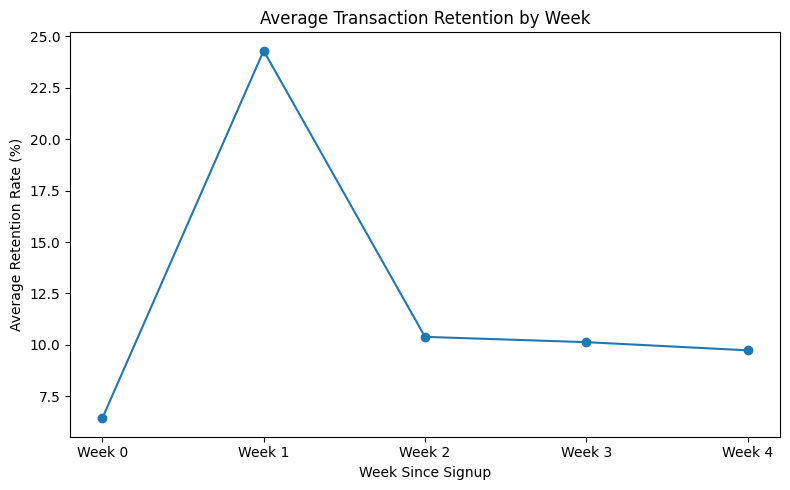

Saved chart to /Users/theboyyy/Work/Projects/fintech-funnel-analysis/reports/charts/average_weekly_retention.png


In [16]:
plt.figure(figsize=(8, 5))
plt.plot(
    retention_summary["week"],
    retention_summary["avg_retention_pct"],
    marker="o",
)
plt.title("Average Transaction Retention by Week")
plt.xlabel("Week Since Signup")
plt.ylabel("Average Retention Rate (%)")
plt.tight_layout()

chart_path = CHARTS_DIR / "average_weekly_retention.png"
plt.savefig(chart_path, dpi=150, bbox_inches="tight")
plt.show()

print(f"Saved chart to {chart_path}")

### Retention Interpretation

Average retention is highest in week 1, reflecting the delay between signup, KYC, deposit, and first transaction in the synthetic product journey.

Retention falls after week 1 and stabilizes around weeks 2–4. This suggests that the product succeeds in moving some users to their first transaction, but repeat engagement is weaker.

Because the dataset is synthetic and does not encode specific product launches or lifecycle campaigns over time, cohort-to-cohort differences should be interpreted cautiously.

## 6. Recommendations

Based on the analysis, the main recommendations are:

1. **Reduce KYC submission friction.**  
   The largest funnel leak occurs before KYC submission. The product team should test clearer KYC prompts, better document upload guidance, progress indicators, and reminder flows.

2. **Improve first deposit conversion after KYC approval.**  
   A large share of approved users still do not make a first deposit. The team should test clearer funding CTAs, more local payment methods, and trust-building messages around deposit safety.

3. **Reallocate spend away from weak paid social acquisition.**  
   Paid social has low activation and weak profitability. It should be narrowed to better-performing audiences or reduced until targeting improves.

4. **Scale referral carefully, not blindly.**  
   Referral users activate strongly, but referral bonuses are expensive. The channel should be optimized around payback, not just activation.

5. **Prioritize cashback-style experiments.**  
   Cashback has strong activation efficiency and lower cost per activated user than referral bonuses. It is a better candidate for controlled incentive testing.

6. **Build lifecycle campaigns after the first transaction.**  
   Retention weakens after early transaction activity. The product should test repeat-use prompts, transaction reminders, and feature education after the first transaction.

## 7. Limitations

This project uses synthetic data, so the findings should be interpreted as a demonstration of analytical workflow rather than evidence about a real fintech product.

Key limitations:

1. The data-generating process was manually designed, so relationships between acquisition channel, activation, incentives, and profitability are simulated.
2. Estimated revenue is simplified and does not include full fintech unit economics such as interchange, FX spread, subscriptions, servicing cost, fraud loss, chargebacks, or cost of capital.
3. Acquisition cost is not modeled separately from incentive cost.
4. Retention is based only on transaction events, not broader engagement events.
5. No causal claim is made about incentives. Higher activation among incentivized users may reflect targeting, selection, or simulated user quality rather than true incentive lift.

Despite these limitations, the project demonstrates a realistic product analytics workflow using SQL, Python, cohort analysis, funnel analysis, and commercial reasoning.

## Executive Summary

The synthetic fintech app converted 29.2% of signed-up users to their first transaction and achieved a 28.7% 14-day activation rate.

The largest onboarding leak occurred between verification completion and KYC submission, where 2,401 users dropped off. This suggests that identity verification is the primary friction point in the early product journey.

Referral and paid search were the strongest acquisition channels by activation rate, while paid social and affiliate users showed weaker activation. However, referral users were expensive to acquire through bonuses, making referrals less attractive in short-term profitability despite strong activation.

Incentives improved activation but were not profitable under the current 30-day revenue assumptions. Cashback was the most efficient incentive type by cost per activated user, while referral bonuses produced high activation at a much higher subsidy cost.

Retention peaked around week 1 and weakened afterward, suggesting that many users complete an initial transaction but do not yet form a durable transaction habit.

Recommended next steps are to reduce KYC friction, improve post-KYC deposit conversion, reallocate weak paid social spend, redesign referral incentives around payback, and run controlled cashback experiments.